# QLoRA Fine-Tuning with a Native PyTorch Training Loop

This notebook trains the **same** QLoRA experiment as `fine_tune_financial.ipynb`
— Qwen2.5-1.5B-Instruct, r=16 / alpha=32 / 4-bit NF4, on the same 104 financial
instruction/target pairs — but the training is written **by hand in PyTorch**:
no `transformers.Trainer`, no `accelerate` training abstractions, no `SFTTrainer`.

Implemented manually:
- a custom `torch.utils.data.Dataset` (prompt tokens masked so loss is on the
  target section only) + a padding `collate` fn,
- the QLoRA adapter applied **directly** via `peft.get_peft_model`,
- a training loop with explicit `loss.backward()`, gradient accumulation, a
  manual cosine-with-warmup LR schedule, gradient clipping, `optimizer.step()`,
  and per-epoch loss logging.

The final section benchmarks this loop against the Hugging Face `Trainer` on the
same data and overlays the two loss curves.

Runs on a free Colab **T4**. Runtime → Change runtime type → T4 GPU.

## 1. Setup

In [1]:
!pip -q install -U "transformers>=4.44" "peft>=0.12" "bitsandbytes>=0.43" "datasets>=2.20" "accelerate>=0.33" matplotlib

import torch
assert torch.cuda.is_available(), "No GPU — Runtime > Change runtime type > T4 GPU"
print("GPU:", torch.cuda.get_device_name(0))

# NB: accelerate is installed only because transformers needs it to *load* a
# 4-bit model (device_map). The training loop below uses none of its
# abstractions — every optimizer/backward/accumulation step is explicit.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 119.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 117.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 20.8 MB/s eta 0:00:00
GPU: Tesla T4


## 2. Load the 104 instruction/target pairs

The same `data/sections_dataset.jsonl` produced by `scripts/build_dataset.py`
(Financial Health + Risk Factors). Upload it, or `git clone` the repo.

In [2]:
import os, json
from collections import Counter

DATA_PATH = "data/sections_dataset.jsonl"
if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        print("Upload sections_dataset.jsonl:")
        up = files.upload()
        DATA_PATH = list(up.keys())[0]
    except Exception:
        raise FileNotFoundError("Provide data/sections_dataset.jsonl (built by scripts/build_dataset.py).")

examples = [json.loads(l) for l in open(DATA_PATH, encoding="utf-8") if l.strip()]
print(f"Loaded {len(examples)} instruction/target pairs")
print(Counter(e["section"] for e in examples))

Upload sections_dataset.jsonl:


Saving sections_dataset.jsonl to sections_dataset.jsonl
Loaded 104 instruction/target pairs
Counter({'### Financial Health': 78, '### Risk Factors': 26})


## 3. Custom `Dataset` + `collate`

`FinancialSectionsDataset` tokenizes each pair with the model's chat template and
masks the prompt tokens with `-100`, so the loss is computed only on the target
section. `collate` pads a batch to its longest sequence.

In [3]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader

MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
MAX_LEN = 1024

tokenizer = AutoTokenizer.from_pretrained(MODEL)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


class FinancialSectionsDataset(Dataset):
    """104 financial instruction/target pairs, tokenized with the prompt masked
    (-100) so the loss is computed only on the assistant section text."""

    def __init__(self, examples, tokenizer, max_len=MAX_LEN):
        self.examples = examples
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        msgs = self.examples[idx]["messages"]
        prompt = self.tokenizer.apply_chat_template(msgs[:-1], tokenize=False, add_generation_prompt=True)
        full = self.tokenizer.apply_chat_template(msgs, tokenize=False)
        p_ids = self.tokenizer(prompt, add_special_tokens=False).input_ids
        f_ids = self.tokenizer(full, add_special_tokens=False).input_ids[:self.max_len]
        labels = list(f_ids)
        for i in range(min(len(p_ids), len(labels))):
            labels[i] = -100  # mask the prompt
        return {"input_ids": f_ids, "labels": labels}


def collate(batch):
    pad_id = tokenizer.pad_token_id
    maxlen = max(len(b["input_ids"]) for b in batch)
    input_ids, attention_mask, labels = [], [], []
    for b in batch:
        n = len(b["input_ids"]); d = maxlen - n
        input_ids.append(b["input_ids"] + [pad_id] * d)
        attention_mask.append([1] * n + [0] * d)
        labels.append(b["labels"] + [-100] * d)
    return {
        "input_ids": torch.tensor(input_ids),
        "attention_mask": torch.tensor(attention_mask),
        "labels": torch.tensor(labels),
    }


dataset = FinancialSectionsDataset(examples, tokenizer)
_sample = dataset[0]
print("dataset size:", len(dataset))
print("sample length:", len(_sample["input_ids"]), "| supervised tokens:",
      sum(1 for x in _sample["labels"] if x != -100))

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

dataset size: 104
sample length: 651 | supervised tokens: 111


## 4. Model + QLoRA adapter (applied directly via `peft`)

Qwen2.5-1.5B loaded in 4-bit NF4, with a LoRA adapter (r=16, alpha=32) attached
via `get_peft_model` — the same config as `fine_tune_financial.ipynb`, but
applied by hand rather than through `SFTTrainer`.

In [4]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training


def build_qlora_model():
    bnb = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True,
    )
    model = AutoModelForCausalLM.from_pretrained(MODEL, quantization_config=bnb, device_map="auto")
    model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
    model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
    lora = LoraConfig(
        r=16, lora_alpha=32, lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    )
    model = get_peft_model(model, lora)
    model.config.use_cache = False
    return model


model = build_qlora_model()
model.print_trainable_parameters()

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


## 5. The native training loop

Everything explicit: forward, `loss.backward()` (scaled for accumulation),
gradient accumulation every `grad_accum` micro-batches, a hand-written
cosine-with-warmup LR schedule, gradient clipping, `optimizer.step()`, and
per-epoch mean-loss logging. It records loss both per micro-batch and per
optimizer step (the latter for an apples-to-apples comparison with the Trainer).

In [5]:
import math


def train_native_loop(model, loader, epochs=3, grad_accum=8, base_lr=2e-4,
                      warmup_ratio=0.03, max_grad_norm=1.0, log_every=10):
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable, lr=base_lr)

    optim_steps_per_epoch = math.ceil(len(loader) / grad_accum)
    total_optim_steps = optim_steps_per_epoch * epochs
    warmup_steps = max(1, int(total_optim_steps * warmup_ratio))

    def lr_at(step):
        if step < warmup_steps:
            return base_lr * (step + 1) / warmup_steps
        progress = (step - warmup_steps) / max(1, total_optim_steps - warmup_steps)
        return 0.5 * base_lr * (1 + math.cos(math.pi * progress))

    model.train()
    micro_losses, optim_losses, epoch_losses = [], [], []
    optim_step, window = 0, []

    for epoch in range(epochs):
        running, count = 0.0, 0
        optimizer.zero_grad()
        for i, batch in enumerate(loader):
            batch = {k: v.to(model.device) for k, v in batch.items()}
            loss = model(**batch).loss
            (loss / grad_accum).backward()          # scale for accumulation

            micro_losses.append(loss.item())
            window.append(loss.item())
            running += loss.item(); count += 1

            if (i + 1) % grad_accum == 0 or (i + 1) == len(loader):
                for g in optimizer.param_groups:    # manual LR schedule
                    g["lr"] = lr_at(optim_step)
                torch.nn.utils.clip_grad_norm_(trainable, max_grad_norm)
                optimizer.step()
                optimizer.zero_grad()
                optim_losses.append(sum(window) / len(window)); window = []
                optim_step += 1

            if (i + 1) % log_every == 0:
                print(f"  epoch {epoch+1} micro-batch {i+1}/{len(loader)}  loss {loss.item():.4f}")

        mean = running / max(count, 1)
        epoch_losses.append(mean)
        print(f"epoch {epoch+1}/{epochs}  mean loss {mean:.4f}")

    return optimizer, micro_losses, optim_losses, epoch_losses

In [6]:
import random, numpy as np


def set_seed(s=0):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)


set_seed(0)
loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=collate)
optimizer, native_micro, native_optim, native_epoch = train_native_loop(model, loader)

  epoch 1 micro-batch 10/52  loss 1.2246
  epoch 1 micro-batch 20/52  loss 0.5281
  epoch 1 micro-batch 30/52  loss 0.4956
  epoch 1 micro-batch 40/52  loss 0.2950
  epoch 1 micro-batch 50/52  loss 0.1758
epoch 1/3  mean loss 0.9709
  epoch 2 micro-batch 10/52  loss 0.0747
  epoch 2 micro-batch 20/52  loss 0.0830
  epoch 2 micro-batch 30/52  loss 0.1042
  epoch 2 micro-batch 40/52  loss 0.9716
  epoch 2 micro-batch 50/52  loss 0.0281
epoch 2/3  mean loss 0.5346
  epoch 3 micro-batch 10/52  loss 0.0412
  epoch 3 micro-batch 20/52  loss 2.1674
  epoch 3 micro-batch 30/52  loss 2.3383
  epoch 3 micro-batch 40/52  loss 0.0418
  epoch 3 micro-batch 50/52  loss 0.0362
epoch 3/3  mean loss 0.4752


## 6. Loss curve (native loop)

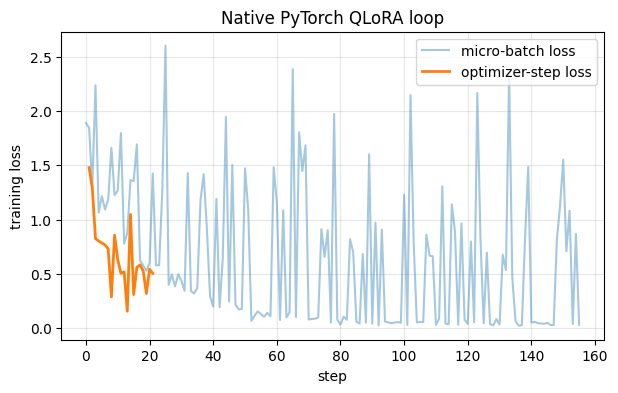

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(native_micro, alpha=.4, label="micro-batch loss")
plt.plot(range(1, len(native_optim) + 1),
         native_optim if len(native_micro) == len(native_optim) else native_optim,
         lw=2, label="optimizer-step loss")
plt.xlabel("step"); plt.ylabel("training loss"); plt.title("Native PyTorch QLoRA loop")
plt.legend(); plt.grid(alpha=.3); plt.show()

## 7. Save the adapter

In [8]:
OUT = "/content/adapters/financial-lora-pytorch"
os.makedirs(OUT, exist_ok=True)
model.save_pretrained(OUT)
tokenizer.save_pretrained(OUT)
print("saved adapter to", OUT, "->", os.listdir(OUT))

saved adapter to /content/adapters/financial-lora-pytorch -> ['tokenizer_config.json', 'adapter_config.json', 'README.md', 'adapter_model.safetensors', 'chat_template.jinja', 'tokenizer.json']


## 8. Benchmark: native loop vs Hugging Face `Trainer`

Train the **same** data + hyperparameters with the HF `Trainer`
(`optim='adamw_torch'`, cosine schedule, warmup 0.03, grad-accum 8 — matched to
the native loop) and overlay the two optimizer-step loss curves. We free the
native model first so the two runs don't both sit on the T4.

In [9]:
import gc

try:
    del model, optimizer
except NameError:
    pass
gc.collect(); torch.cuda.empty_cache()


def train_hf_trainer(dataset, collate):
    from transformers import Trainer, TrainingArguments
    set_seed(0)
    hf_model = build_qlora_model()
    args = TrainingArguments(
        output_dir="/content/hf-trainer-run",
        per_device_train_batch_size=2,
        gradient_accumulation_steps=8,
        num_train_epochs=3,
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        warmup_ratio=0.03,
        max_grad_norm=1.0,
        optim="adamw_torch",     # same optimizer as the native loop
        logging_steps=1,         # one log per optimizer step
        bf16=True,
        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False},
        save_strategy="no",
        report_to="none",
    )
    trainer = Trainer(model=hf_model, args=args, train_dataset=dataset, data_collator=collate)
    trainer.train()
    losses = [h["loss"] for h in trainer.state.log_history if "loss" in h]
    return losses, hf_model


hf_optim_losses, hf_model = train_hf_trainer(dataset, collate)
print("native optimizer steps:", len(native_optim), "| HF Trainer logged steps:", len(hf_optim_losses))

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
1,1.355769
2,1.521788
3,1.246263
4,0.867864
5,0.901747
6,0.974030
7,0.685913
8,0.382896
9,0.642118
10,0.228487


native optimizer steps: 21 | HF Trainer logged steps: 21


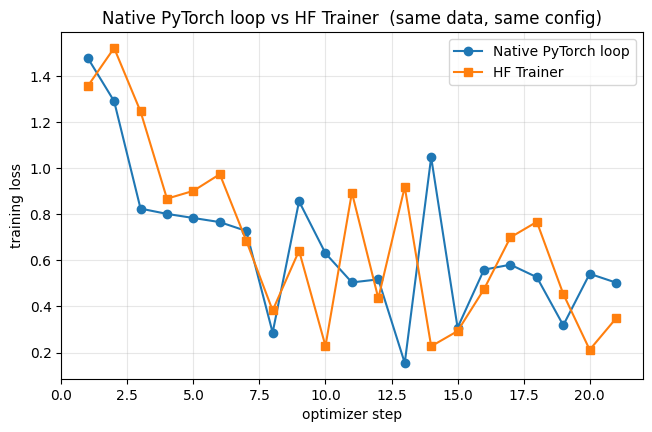

final loss  — native: 0.5035   HF Trainer: 0.3489


In [10]:
plt.figure(figsize=(7.5, 4.5))
plt.plot(range(1, len(native_optim) + 1), native_optim, "o-", label="Native PyTorch loop")
plt.plot(range(1, len(hf_optim_losses) + 1), hf_optim_losses, "s-", label="HF Trainer")
plt.xlabel("optimizer step"); plt.ylabel("training loss")
plt.title("Native PyTorch loop vs HF Trainer  (same data, same config)")
plt.legend(); plt.grid(alpha=.3); plt.show()

print(f"final loss  — native: {native_optim[-1]:.4f}   HF Trainer: {hf_optim_losses[-1]:.4f}")

**What to look for.** With matched hyperparameters and optimizer, the two
curves should track closely and converge to a similar final training loss —
evidence that the hand-written loop reproduces the `Trainer`'s behavior. Small
divergences are expected (data-shuffle order, non-determinism in 4-bit kernels).
Record the final losses and paste the chart into the README section.